# 660 sharpness across Mg/Si and potential temperature

Two thermal limits for the ringwoodite -> bridgmanite + ferropericlase transition:

* **adiabatic** (Pe -> inf) -- the true isentrope. Latent heat cools the reacting
  interval; the negative Clapeyron slope pushes completion deeper.
* **conductive** (Pe -> 0) -- conduction resupplies the latent heat, so T continues
  along the reaction-free adiabatic gradient from the temperature maximum.

The transition window is picked from **seismic properties only** (`Vs`), never from
phase abundances: `dVs/dP` locates it, `d2Vs/dP2` bounds it.

Data are 3-D throughout: `(composition, potential temperature, pressure)`.


In [1]:
import warnings, numpy as np, torch
warnings.filterwarnings('ignore')
from ngibbs.engine.models import HeFESToEmulatorCPU as E

BSE  = {'SiO2':45.0,'Al2O3':4.45,'FeO':7.75,'Fe2O3':0.35,'MgO':37.8,'CaO':3.55,'Na2O':0.36,'Cr2O3':0.38}
MW   = {'SiO2':60.084,'Al2O3':101.961,'FeO':71.844,'Fe2O3':159.688,'MgO':40.304,'CaO':56.077,'Na2O':61.979,'Cr2O3':151.990}
OX   = list(BSE)
hT   = ['P(GPa)(System_main)','T(K)(System_main)'] + OX
hS   = ['P(GPa)(System_main)','S(J/g/K)(System_main)'] + OX

MGSI = np.arange(1.30, 0.79, -0.05)          # 11 compositions
TPC  = np.arange(1200., 1651., 50.)          # 10 potential temperatures, degC
TPK  = TPC + 273.15
NC, NT = len(MGSI), len(TPK)

def comps_for_mgsi(targets, base=BSE):
    """Symmetric, opposite delta on Mg and Si moles; oxides renormalised to 100 wt%."""
    n = {k: base[k]/MW[k] for k in base}                 # moles per 100 g
    n['MgO'] += 0                                        # Mg and Si are 1:1 per oxide formula
    out = np.empty((len(targets), len(OX)))
    for i, R in enumerate(targets):
        d = (R*n['SiO2'] - n['MgO']) / (1.0 + R)         # (nMg+d)/(nSi-d) = R
        m = dict(n); m['MgO'] = n['MgO'] + d; m['SiO2'] = n['SiO2'] - d
        w = np.array([m[k]*MW[k] for k in OX])
        out[i] = 100.0 * w / w.sum()
    return out

WT  = comps_for_mgsi(MGSI)                               # (NC, n_ox) wt%
REF = (BSE['MgO']/MW['MgO']) / (BSE['SiO2']/MW['SiO2'])
print(f"reference BSE Mg/Si = {REF:.3f}   grid {MGSI[0]:.2f} -> {MGSI[-1]:.2f}   {NC} x {NT} = {NC*NT} profiles")


reference BSE Mg/Si = 1.252   grid 1.30 -> 0.80   11 x 10 = 110 profiles


## Pass 1 -- coarse isentropes, 0-30 GPa at 0.1 GPa

One batched call. `get_isentrope` mode B takes one row per profile, with the
temperature column acting as that row's potential temperature.


In [2]:
P1 = np.arange(0., 30.01, 0.1)                            # 301
feat = np.zeros((NC*NT, len(hS)), dtype=np.float32)
feat[:, 1] = np.repeat(TPK[None, :], NC, 0).ravel()       # T column = Tp
feat[:, 2:] = np.repeat(WT, NT, axis=0)

T1, _, pr1 = E.get_isentrope(features=feat, headers=hT, pressures=P1,
                             properties=['rho','Vp','Vs'])
r3 = lambda a: np.asarray(a).reshape(NC, NT, len(P1))
T1, rho1, Vp1, Vs1 = r3(T1.numpy()), r3(pr1['rho']), r3(pr1['Vp']), r3(pr1['Vs'])
S_ref = feat  # keep design for reuse
print("pass 1:", T1.shape, f"{T1.size} assemblages")


Processing batches of size 32768: 100%|██████████| 1/1 [00:00<00:00,  4.00it/s]

pass 1: (11, 10, 301) 33110 assemblages


## Locate the transition from `dVs/dP`, then resample

Centred finite difference on the coarse grid; the largest `|dVs/dP|` inside a
18-28 GPa search band is the transition centre. The band is the only prior used --
it keeps the finder off the 410 and off low-pressure assemblage changes, both of
which can carry a larger `|dVs/dP|` than the 660 in some cells.

The fine window runs 0.5 GPa shallower to 1.0 GPa deeper at 0.01 GPa and is swept
with the **isentropic** net to get the adiabatic `T(P)`.


In [3]:
from scipy.ndimage import median_filter

PBAND = (18., 28.)
NF, NFIT, NX = 151, 40, 100

def ddP(Y, P, axis=-1):
    return np.gradient(Y, P, axis=axis)

# Centre on the largest Vs *step* across a 0.5 GPa sliding interval rather than the
# largest single-sample derivative: several gates sit inside the band and the sharpest
# one is not always the post-spinel step.
HW = 3                                                                  # 0.3 GPa each side
step = Vs1[..., 2*HW:] - Vs1[..., :-2*HW]
Pmid = P1[HW:-HW]
band = (Pmid >= PBAND[0]) & (Pmid <= PBAND[1])
Pc = Pmid[band][np.argmax(step[..., band], axis=-1)]                    # (NC, NT)
Pfine = Pc[..., None] + np.linspace(-0.5, 1.0, NF)                     # (NC, NT, NF)

def ref_entropy(wt, Tk):
    f = np.zeros((len(Tk), len(hT)), dtype=np.float32)
    f[:, 0] = 1e-4; f[:, 1] = Tk; f[:, 2:] = wt
    cm = E.ForwardMB(f, headers=hT, outputs=['component_moles'])['component_moles'].to(torch.float64)
    PT = torch.tensor(np.stack([np.full(len(Tk), 1e-4), Tk], 1), dtype=torch.float64)
    return np.asarray(E.get_property_hefesto_vectorized_from_assemblage(cm, PT, ('S',))['S'])

S = ref_entropy(np.repeat(WT, NT, axis=0), np.tile(TPK, NC)).reshape(NC, NT)

def _oxblock(n):
    return np.repeat(np.repeat(WT, NT, axis=0), n, axis=0)

def isen(P, S):
    f = np.zeros((P.size, len(hS)), dtype=np.float32)
    f[:, 0] = P.ravel()
    f[:, 1] = np.repeat(S.ravel(), P.shape[-1])
    f[:, 2:] = _oxblock(P.shape[-1])
    return E.ForwardMB(f, headers=hS, outputs=['temperature'])['temperature']\
            .detach().numpy().reshape(P.shape)

def repair(T, tol=60., w=21):
    """The T-from-S network throws ~0.07 GPa excursions of up to 500 K next to phase
    gates. They are 0.3% of samples and an order of magnitude larger than the real
    latent-heat step (~30 K), so flag against a wide running median and interpolate
    across. Genuine steps are left alone."""
    bad = np.abs(T - median_filter(T, size=(1, 1, w), mode='nearest')) > tol
    out = T.copy()
    for idx in zip(*np.where(bad.any(-1))):
        m = bad[idx]; k = np.arange(T.shape[-1])
        out[idx][m] = np.interp(k[m], k[~m], T[idx][~m])
    return out, bad

Tad, spiked = repair(isen(Pfine, S))
print(f"repaired {spiked.sum()} of {spiked.size} samples ({100*spiked.sum()/spiked.size:.2f}%)")
print("pass 2a:", Tad.shape, f"{Tad.size} assemblages")


repaired 0 of 16610 samples (0.00%)
pass 2a: (11, 10, 151) 16610 assemblages


## Conductive branch

The reaction-free gradient is the **median** point-to-point slope over the
shallowest 0.4 GPa of the window -- median rather than least squares so a gate
inside the fit region cannot drag it. The conductive path leaves the adiabat at
the temperature maximum and continues on that gradient for 100 steps.


In [4]:
# Fitted on the DEEP side of the window, not the shallow side: the post-garnet ramp
# (majorite dissolving into bridgmanite) runs right up to the post-spinel step, so
# nothing above the transition is reaction-free. Below it the assemblage is fixed.
# Median of point-to-point slopes so a gate inside the fit region cannot drag it.
GAM = np.median(np.diff(Tad[..., -NFIT:], axis=-1) /
                np.diff(Pfine[..., -NFIT:], axis=-1), axis=-1)         # (NC, NT) K/GPa

imax = np.argmax(Tad, axis=-1)
Pmax = np.take_along_axis(Pfine, imax[..., None], -1)
Tmax = np.take_along_axis(Tad,   imax[..., None], -1)
Pcond = Pmax + np.arange(1, NX+1) * 0.01
Tcond = Tmax + GAM[..., None] * (Pcond - Pmax)
ok_dip = imax < NF - 1                                                  # dip found inside window
print(f"gamma median {np.median(GAM):.1f} K/GPa  (5-95%: {np.percentile(GAM,5):.1f} to {np.percentile(GAM,95):.1f})")
print(f"temperature maximum inside the window for {ok_dip.sum()}/{ok_dip.size} profiles")


gamma median 20.5 K/GPa  (5-95%: 9.0 to 40.3)
temperature maximum inside the window for 55/110 profiles


## Pass 2b -- both branches through the **same** isothermal net

Running the adiabat's own `(P, T)` back through the isothermal model makes the two
branches self-consistent, so any difference between them is physics rather than a
disagreement between two networks.


In [5]:
def isotherm(P, T):
    f = np.zeros((P.size, len(hT)), dtype=np.float32)
    f[:, 0] = P.ravel(); f[:, 1] = T.ravel(); f[:, 2:] = _oxblock(P.shape[-1])
    cm = E.ForwardMB(f, headers=hT, outputs=['component_moles'])['component_moles'].to(torch.float64)
    pr = E.get_property_hefesto_vectorized_from_assemblage(
        cm, torch.tensor(np.stack([P.ravel(), T.ravel()], 1), dtype=torch.float64),
        ('rho','Vp','Vs'))
    return ({k: np.asarray(v).reshape(P.shape) for k, v in pr.items()},
            cm.numpy().reshape(*P.shape, -1))

AD, cmAD = isotherm(Pfine, Tad)
CD, cmCD = isotherm(Pcond, Tcond)
print("pass 2b:", Tad.size + Tcond.size, "assemblages")


pass 2b: 27610 assemblages


## Transition window from `d2Vs/dP2`

The window opens at the maximum of the second derivative and closes at the minimum.
Nothing here uses phase abundances -- only `Vs`, which is what seismology sees.


In [6]:
EDGE = 5

def window(Vs, P):
    d2 = np.gradient(np.gradient(Vs, axis=-1), axis=-1) / np.diff(P, axis=-1)[..., :1]**2
    core = d2[..., EDGE:-EDGE]
    top  = np.argmax(core, -1) + EDGE
    base = np.argmin(core, -1) + EDGE
    return top, base, (base > top)

def gather(A, idx):
    return np.take_along_axis(A, idx[..., None], -1)[..., 0]


## Radial integration, rho(P) -> depth

`dP/dz = rho g` with `g = GM(r)/r^2`, marching down from the surface and removing
each shell's mass as it is passed. Uses the coarse-pass densities, then interpolates
onto each profile's own fine grid.


In [7]:
G, R_E, M_E = 6.674e-11, 6.371e6, 5.972e24

def depth_of_P(rho, P):
    r = np.full(rho.shape[:-1], R_E); M = np.full(rho.shape[:-1], M_E)
    z = np.zeros_like(rho)
    for k in range(1, P.size):
        rk = 0.5*(rho[..., k] + rho[..., k-1]) * 1e3
        dz = (P[k]-P[k-1])*1e9 / (rk * G*M/r**2)
        z[..., k] = z[..., k-1] + dz
        M = M - 4*np.pi*r**2 * rk * dz; r = r - dz
    return z / 1e3                                        # km

def interp_rows(xq, x, Y):
    j = np.clip(np.searchsorted(x, xq) - 1, 0, len(x)-2)
    w = (xq - x[j]) / (x[j+1] - x[j])
    return np.take_along_axis(Y, j, -1)*(1-w) + np.take_along_axis(Y, j+1, -1)*w

Z1 = depth_of_P(rho1, P1)                                 # (NC, NT, 301) km
Zad, Zcd = interp_rows(Pfine, P1, Z1), interp_rows(Pcond, P1, Z1)
print(f"depth at 23.4 GPa: {interp_rows(np.full((NC,NT,1),23.4), P1, Z1).mean():.0f} km (PREM 659)")


depth at 23.4 GPa: 655 km (PREM 659)


## Metrics, with a validity mask

A cell is kept only if the temperature maximum falls inside the window, the fitted
adiabatic gradient is physical (4-15 K/GPa), and both `d2Vs/dP2` windows are ordered.


In [8]:
res = {}
for tag, (Vs, Z, Pg) in {'adiabatic': (AD['Vs'], Zad, Pfine),
                         'conductive': (CD['Vs'], Zcd, Pcond)}.items():
    t, b, okw = window(Vs, Pg)
    res[tag] = dict(base=gather(Z, b), thick=gather(Z, b)-gather(Z, t),
                    dVs=100*(gather(Vs, b)-gather(Vs, t))/gather(Vs, t), ok=okw)

MASK = res['adiabatic']['ok'] & res['conductive']['ok'] & ok_dip & (GAM > 4) & (GAM < 15)
for tag in res:
    for k in ('base','thick','dVs'):
        res[tag][k] = np.where(MASK, res[tag][k], np.nan)
print(f"valid cells: {MASK.sum()}/{MASK.size}")
print("valid by Tp (degC):", dict(zip(TPC.astype(int), MASK.sum(0))))
for tag in res:
    v = res[tag]
    print(f"{tag:11s} base {np.nanmin(v['base']):.0f}-{np.nanmax(v['base']):.0f} km  "
          f"thick {np.nanmin(v['thick']):.2f}-{np.nanmax(v['thick']):.2f} km  "
          f"dVs {np.nanmin(v['dVs']):.1f}-{np.nanmax(v['dVs']):.1f}%")


valid cells: 34/110
valid by Tp (degC): {1200: 11, 1250: 8, 1300: 6, 1350: 6, 1400: 1, 1450: 2, 1500: 0, 1550: 0, 1600: 0, 1650: 0}
adiabatic   base 621-654 km  thick 0.47-2.13 km  dVs 2.0-6.3%
conductive  base 619-653 km  thick 0.47-1.47 km  dVs 1.6-6.3%


## Heat maps

Mg/Si on x, potential temperature on y. Blank cells failed the validity mask.


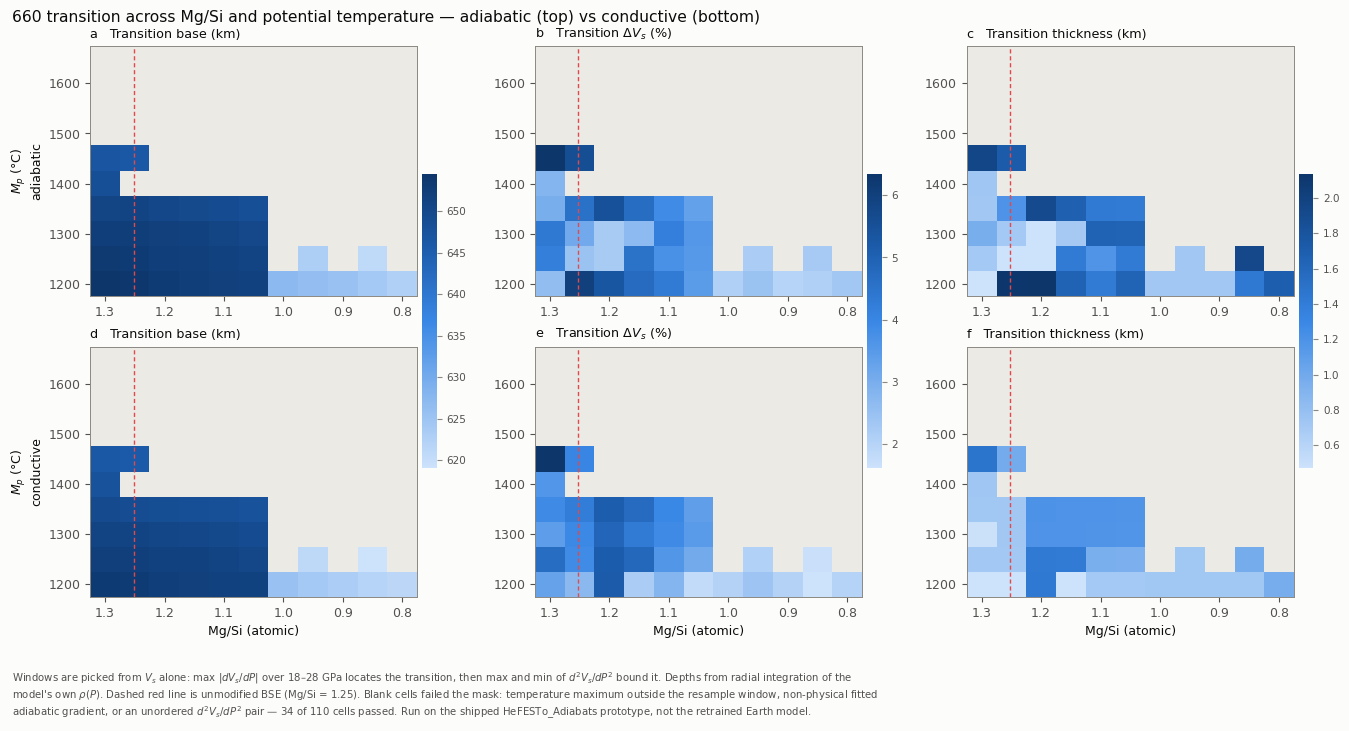

In [10]:
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

INK, INK2, MUTED, SURF = '#0b0b0b', '#52514e', '#8a8880', '#fcfcfb'
SEQ = LinearSegmentedColormap.from_list('seq', ['#cde2fb','#86b6ef','#3987e5','#1c5cab','#0d366b'])
SEQ.set_bad('#eceae5')
plt.rcParams.update({'font.size':9,'axes.edgecolor':MUTED,'axes.linewidth':0.7,
    'xtick.color':INK2,'ytick.color':INK2,'axes.labelcolor':INK,'text.color':INK,
    'figure.facecolor':SURF,'axes.facecolor':SURF,'legend.frameon':False,
    'font.family':'DejaVu Sans'})

PANELS = [('base',  'Transition base (km)',      '%.0f'),
          ('dVs',   'Transition $\\Delta V_s$ (%)', '%.1f'),
          ('thick', 'Transition thickness (km)', '%.1f')]

def heatmaps():
    fig, AX = plt.subplots(2, 3, figsize=(13.4, 6.2), layout='constrained')
    for c, (key, lab, fmt) in enumerate(PANELS):
        # one scale per quantity, shared by both cases, so the rows are comparable
        both = np.concatenate([res[t][key].ravel() for t in ('adiabatic','conductive')])
        vmin, vmax = np.nanmin(both), np.nanmax(both)
        for r, tag in enumerate(('adiabatic','conductive')):
            ax = AX[r, c]; V = np.ma.masked_invalid(res[tag][key].T)
            im = ax.imshow(V, origin='lower', cmap=SEQ, aspect='auto', vmin=vmin, vmax=vmax,
                           extent=[MGSI[0]+0.025, MGSI[-1]-0.025, TPC[0]-25, TPC[-1]+25])
            ax.set_title(f"{'abcdef'[r*3+c]}   {lab}", loc='left', fontsize=9.2, pad=6)
            if r == 1: ax.set_xlabel('Mg/Si (atomic)')
            if c == 0: ax.set_ylabel(f'$M_p$ (°C)\n{tag}', fontsize=9)
            ax.set_xticks(MGSI[::2]); ax.set_yticks(TPC[::2]); ax.grid(False)
            ax.axvline(REF, color='#e34948', lw=1.0, ls=(0,(3,2)))
        cb = fig.colorbar(im, ax=[AX[0, c], AX[1, c]], pad=0.015, fraction=0.045, shrink=0.92)
        cb.outline.set_visible(False); cb.ax.tick_params(labelsize=7.5, color=MUTED)
    fig.suptitle('660 transition across Mg/Si and potential temperature — adiabatic (top) vs conductive (bottom)',
                 x=0.005, ha='left', fontsize=11.2, y=1.02)
    fig.get_layout_engine().set(w_pad=0.05, wspace=0.06)
    fig.text(0.005, -0.045,
      'Windows are picked from $V_s$ alone: max $|dV_s/dP|$ over 18–28 GPa locates the transition, then max and min of $d^2V_s/dP^2$ bound it. Depths from radial integration of the\n'
      'model\'s own $\\rho(P)$. Dashed red line is unmodified BSE (Mg/Si = %.2f). Blank cells failed the mask: temperature maximum outside the resample window, non-physical fitted\n'
      'adiabatic gradient, or an unordered $d^2V_s/dP^2$ pair — %d of %d cells passed. Run on the shipped HeFESTo_Adiabats prototype, not the retrained Earth model.'
      % (REF, MASK.sum(), MASK.size), ha='left', va='top', fontsize=7.3, color=INK2)
    return fig

heatmaps().savefig('fig_heatmaps.png', dpi=200, bbox_inches='tight', facecolor=SURF)


## Context profiles

A 3 GPa window around one cell, both thermal paths, on the same three views as before.


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\dashf\anaconda3\envs\torch-env\lib\site-packages\IPython\core\interactiveshell.py", line 3579, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\dashf\AppData\Local\Temp\ipykernel_26000\161896636.py", line 64, in <module>
    context_fig(iv, jv).savefig('/home/claude/nb/fig_context.png', dpi=200, bbox_inches='tight', facecolor=SURF)
  File "c:\Users\dashf\anaconda3\envs\torch-env\lib\site-packages\matplotlib\figure.py", line 3490, in savefig
    self.canvas.print_figure(fname, **kwargs)
  File "c:\Users\dashf\anaconda3\envs\torch-env\lib\site-packages\matplotlib\backend_bases.py", line 2184, in print_figure
    result = print_method(
  File "c:\Users\dashf\anaconda3\envs\torch-env\lib\site-packages\matplotlib\backend_bases.py", line 2040, in <lambda>
    print_method = functools.wraps(meth)(lambda *args, **kwargs: meth(
  File "c:\Users\dashf\anaconda3\envs\torch-env\lib\site-packages\matplotlib\backen

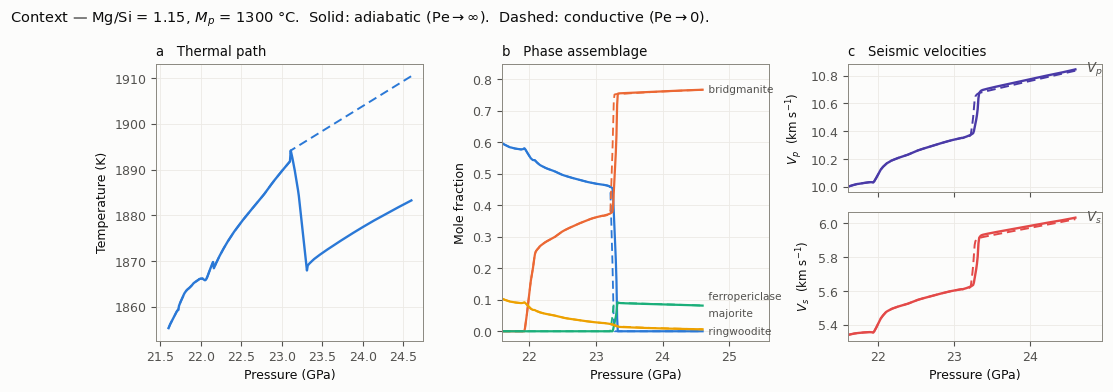

In [11]:
LAB = list(E.isothermal_emulator.ml_indexer.label_names)
GRP = {'ringwoodite':['mg-ringwoodite','fe-ringwoodite'], 'bridgmanite':['mg-bridgmanite','fe-bridgmanite'],
       'ferropericlase':['periclase','wustite'], 'majorite':['mg-majorite','na-majorite']}
IDX = {k: [LAB.index(n) for n in v if n in LAB] for k, v in GRP.items()}
BLUE, ORANGE, AQUA, YELL, VIOL, RED = '#2a78d6','#eb6834','#1baf7a','#eda100','#4a3aa7','#e34948'
PH = list(zip(GRP, (BLUE, ORANGE, AQUA, YELL)))

def context(ic, it, half=1.5, dp=0.01):
    P = (Pc[ic, it] + np.arange(-half, half+dp/2, dp))[None, None, :]
    wt = WT[ic:ic+1]
    def _run(Pq, Tq):
        f = np.zeros((Pq.size, len(hT)), dtype=np.float32)
        f[:, 0] = Pq.ravel(); f[:, 1] = Tq.ravel(); f[:, 2:] = wt
        cm = E.ForwardMB(f, headers=hT, outputs=['component_moles'])['component_moles'].to(torch.float64)
        pr = E.get_property_hefesto_vectorized_from_assemblage(
            cm, torch.tensor(np.stack([Pq.ravel(), Tq.ravel()], 1), dtype=torch.float64), ('Vp','Vs'))
        a = cm.numpy(); fr = a/np.clip(a.sum(1, keepdims=True), 1e-30, None)
        return {k: np.asarray(v).ravel() for k, v in pr.items()}, \
               {k: fr[:, v].sum(1) for k, v in IDX.items()}
    fS = np.zeros((P.size, len(hS)), dtype=np.float32)
    fS[:, 0] = P.ravel(); fS[:, 1] = S[ic, it]; fS[:, 2:] = wt
    Ta = repair(E.ForwardMB(fS, headers=hS, outputs=['temperature'])['temperature']
                .detach().numpy().reshape(P.shape))[0]
    km = int(np.argmax(Ta)); Tc = np.where(np.arange(P.size) < km, Ta.ravel(),
             Ta.ravel()[km] + GAM[ic, it]*(P.ravel()-P.ravel()[km]))[None, None, :]
    pa, fa = _run(P, Ta); pc, fc = _run(P, Tc)
    return P.ravel(), Ta.ravel(), Tc.ravel(), pa, fa, pc, fc

def _spread(v, gap=0.055):
    o = np.argsort(v); out = np.array(v, float)
    for k in range(1, len(o)):
        if out[o[k]] - out[o[k-1]] < gap: out[o[k]] = out[o[k-1]] + gap
    return out

def context_fig(ic, it):
    P, Ta, Tc, pa, fa, pc, fc = context(ic, it)
    fig = plt.figure(figsize=(12.2, 3.6))
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.95], hspace=0.15, wspace=0.30)
    ax = [fig.add_subplot(gs[:, 0]), fig.add_subplot(gs[:, 1])]
    vax = [fig.add_subplot(gs[0, 2]), None]
    vax[1] = fig.add_subplot(gs[1, 2], sharex=vax[0])
    ax[0].plot(P, Ta, color=BLUE, lw=1.7); ax[0].plot(P, Tc, color=BLUE, lw=1.4, ls=(0,(4.5,2.5)))
    ax[0].set_ylabel('Temperature (K)'); ax[0].set_title('a   Thermal path', loc='left', fontsize=9.5, pad=6)
    ends = _spread([fa[nm][-1] for nm, _ in PH])
    for (nm, cl), ye in zip(PH, ends):
        ax[1].plot(P, fa[nm], color=cl, lw=1.6); ax[1].plot(P, fc[nm], color=cl, lw=1.3, ls=(0,(4.5,2.5)))
        ax[1].text(P[-1]+0.04, ye, ' '+nm, fontsize=7.6, color=INK2, va='center')
    ax[1].set_ylabel('Mole fraction'); ax[1].set_xlim(P[0], P[-1]+1.0); ax[1].set_ylim(-0.03, 0.85)
    ax[1].set_title('b   Phase assemblage', loc='left', fontsize=9.5, pad=6)
    for a, k, cl in ((vax[0],'Vp',VIOL), (vax[1],'Vs',RED)):
        a.plot(P, pa[k], color=cl, lw=1.7); a.plot(P, pc[k], color=cl, lw=1.4, ls=(0,(4.5,2.5)))
        a.set_xlim(P[0], P[-1]+0.35)
        a.text(P[-1]+0.04, pa[k][-1], f'  ${k[0]}_{k[1]}$', fontsize=9.5, color=INK2, va='center')
        a.set_ylabel(f'${k[0]}_{k[1]}$  (km s$^{{-1}}$)', fontsize=8.5)
    vax[0].tick_params(labelbottom=False); vax[1].set_xlabel('Pressure (GPa)')
    vax[0].set_title('c   Seismic velocities', loc='left', fontsize=9.5, pad=6)
    for a in ax + vax: a.set_xlabel(a.get_xlabel() or 'Pressure (GPa)'); a.grid(color='#eceae5', lw=0.6)
    vax[0].set_xlabel('')
    fig.suptitle('Context — Mg/Si = %.2f, $M_p$ = %d °C.  Solid: adiabatic (Pe$\\rightarrow\\infty$).  Dashed: conductive (Pe$\\rightarrow$0).'
                 % (MGSI[ic], TPC[it]), x=0.005, ha='left', fontsize=10.5, y=1.03)
    return fig

iv, jv = np.argwhere(MASK)[len(np.argwhere(MASK))//2]
context_fig(iv, jv).savefig('/home/claude/nb/fig_context.png', dpi=200, bbox_inches='tight', facecolor=SURF)
print("context cell:", f"Mg/Si={MGSI[iv]:.2f} Tp={TPC[jv]:.0f}C")


## Any other cell

`context_fig(ic, it)` takes composition and temperature indices.


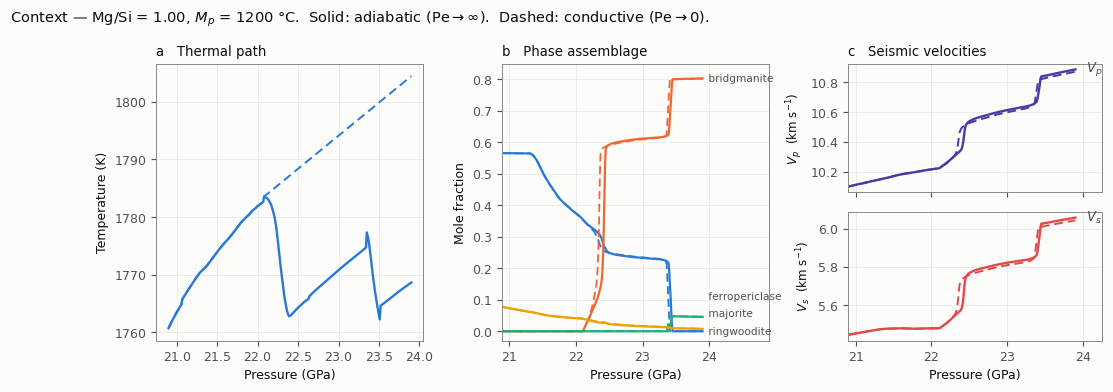

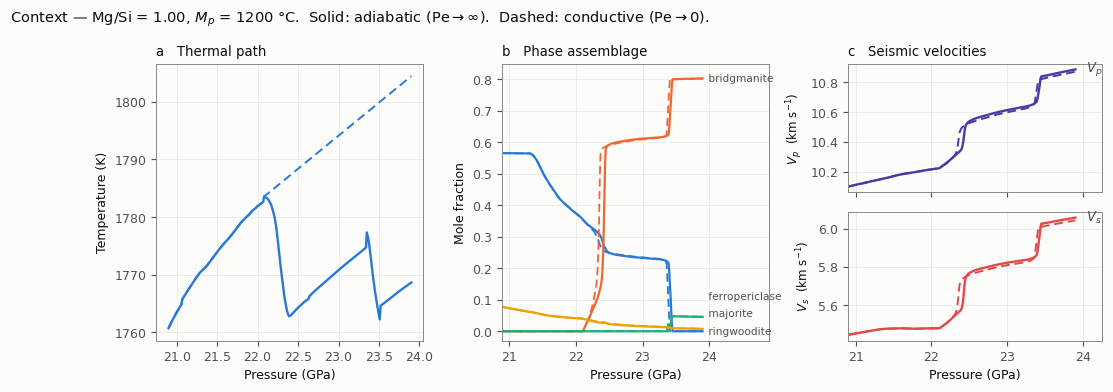

In [12]:
context_fig(np.argmin(np.abs(MGSI-1.00)), 0)
